In [1]:
# Imports

import pyglet
pyglet.options["headless"] = True


import warp as wp

import numpy as np
import pickle

from src.render import PyVistaInterface, WarpMovieRenderer
from src.simulator import mech_step_sticky, chem_step, growth_step, gen_key_array, division_losses, division_logic

from sklearn.preprocessing import MinMaxScaler
from tqdm import trange

import pyvista as pv
import os



# pv.global_theme.trame.jupyter_extension_enabled = True
# pv.global_theme.trame.server_proxy_enabled = False
# os.environ["PYVISTA_OFF_SCREEN"] = "true"
pv.set_jupyter_backend('html')



def fibonacci_sphere_points(num_points, radius):
    points = np.zeros((num_points, 3))
    phi = np.pi * (3. - np.sqrt(5.))

    for i in range(num_points):
        y = 1 - (i / float(num_points - 1)) * 2 
        r = np.sqrt(1 - y * y) 
        theta = phi * i 

        x = np.cos(theta) * r
        z = np.sin(theta) * r

        points[i] = [x * radius, y * radius, z * radius]

    return points


def save_state(centers, radii, radii_eq, activators, inhibitors, particle_count, fname):
    with open(f'Checkpoints/{fname}.pkl', 'wb') as f:
        pickle.dump((centers, radii, radii_eq, activators, inhibitors, particle_count), f)


def load_state(fname):
    with open(f'Checkpoints/{fname}.pkl', 'rb') as f:
        state = pickle.load(f)

    return state

wp.init()
wp.clear_kernel_cache()
wp.clear_lto_cache()


Warp 1.11.0 initialized:
   CUDA Toolkit 12.9, Driver 12.4
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA H100 NVL" (93 GiB, sm_90, mempool enabled)
   Kernel cache:
     /insomnia001/home/ob2391/.cache/warp/1.11.0


## Setup

In [2]:
############################################################
############################################################
############################################################

        # PATTERN PARAMETERS

############################################################
############################################################
############################################################

particle_count = 100
dt_mech = 1e-2
dt_chem = 1e-2
max_particles = 3000


D_I = 10
spat_char = 5e-2
temp_char = 1e-2

    
hill_alpha = 10.  # How steep the function is, 10 is pretty much a step function
switch_conc = 0.01   # Controls growth, higher means need more activators (concentrated growth)
np.random.seed(42)    

In [3]:
# Sample points in space
centers, radii, radii_eq, activators, inhibitors = np.full((max_particles, 3), np.array([0.,0.,0.])), np.full((max_particles,), -1000.), np.full((max_particles,), -1000.), np.full((max_particles,), 0.), np.full((max_particles,), 0.)

rad_proto = np.full((particle_count,), 0.6) 

radii[:particle_count] = rad_proto
radii_eq[:particle_count] = rad_proto


# Chemicals
act_mu = (((rad_proto**3) * 0.75) / 2.).mean()
inhib_mu = (((rad_proto**3) * 0.75) / 10.).mean()
act_sigma, inhib_sigma = 0.001, 0.001


# key, subkey = random.split(key)
activators[:particle_count] = act_mu + act_sigma * np.random.normal(size=(particle_count,))
inhibitors[:particle_count] = inhib_mu + inhib_sigma * np.random.normal(size=(particle_count,))

centers[:particle_count] = fibonacci_sphere_points(particle_count, 0.5)


# polarities
polarities = np.zeros((max_particles, 3), dtype=np.float64)
vesicle_center = centers[:particle_count].mean(axis=0)


p = centers[:particle_count] - vesicle_center
norms = np.linalg.norm(p, axis=1, keepdims=True)
polarities[:particle_count] = p / np.clip(norms, 1e-12, None)


plotter = PyVistaInterface.draw_3d_view(centers, radii, MinMaxScaler(feature_range=(0, 0.9)).fit_transform((activators * 0.75 / (radii**3)).reshape(-1,1)).flatten(), particle_count, blim=-15, tlim=15, alpha=1)
plotter.show()

2026-02-17 23:12:23.290 (   9.077s) [    1502CB820740]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

## Move

In [4]:
R = wp.from_numpy(radii,   dtype=wp.float32, device="cuda")
X = wp.from_numpy(centers, dtype=wp.vec3f, device="cuda")
X_next = wp.zeros_like(X, device="cuda")


for i in trange(10000):
    mech_step_sticky(X, R, particle_count, dt_mech, X, grad_consist=False)

 17%|████████████████████████████▋                                                                                                                                         | 1728/10000 [00:02<00:10, 812.94it/s]

Module src.simulator 8e1a5bb load on device 'cuda:0' took 2888.46 ms  (compiled)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:03<00:00, 2887.23it/s]


In [5]:
plotter = PyVistaInterface.draw_3d_view(X.numpy(), R.numpy(), MinMaxScaler(feature_range=(0, 0.9)).fit_transform((activators * 0.75 / (radii**3)).reshape(-1,1)).flatten(), particle_count, blim=-15, tlim=15, alpha=1)
plotter.show()

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

## Chemicals

In [6]:
A = wp.from_numpy(activators,   dtype=wp.float32, device="cuda")
I = wp.from_numpy(inhibitors, dtype=wp.float32, device="cuda")
R = wp.from_numpy(radii,   dtype=wp.float32, device="cuda")
X = wp.from_numpy(centers, dtype=wp.vec3f, device="cuda")

S = wp.full(1, value=5e-2, dtype=wp.float32)
T = wp.full(1, value=1e-2, dtype=wp.float32)
phi = 10.

dt_chem=1e-1

lapA, lapI = wp.zeros_like(A, device="cuda"), wp.zeros_like(I, device="cuda")

a_s, i_s = [], []

for i in trange(10000):
    mech_step_sticky(X, R, particle_count, dt_mech, X, grad_consist=False)

for t in trange(50000):
    lapA.zero_()
    lapI.zero_()
    
    chem_step(A, I, X, R, lapA, lapI, S, T, phi, dt_chem, particle_count, A, I, grad_consist=False)
    
    a_s.append(A.numpy())
    i_s.append(I.numpy())

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [00:07<00:00, 6523.23it/s]


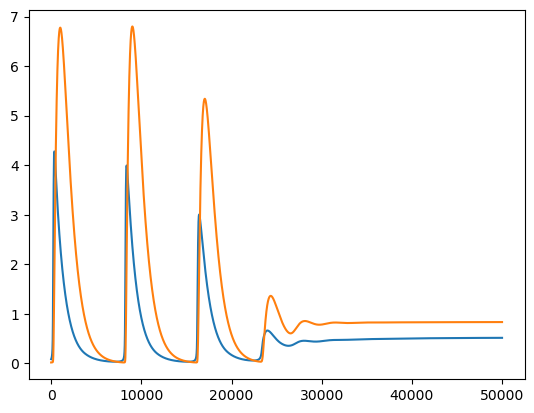

In [7]:
import matplotlib.pyplot as plt
plt.plot([a_s[i][0] for i in range(len(a_s))])
plt.plot([i_s[i][0] for i in range(len(i_s))])

In [8]:
plotter = PyVistaInterface.draw_3d_view(X.numpy(), R.numpy(), MinMaxScaler(feature_range=(0, 0.9)).fit_transform((A.numpy() * 0.75 / (R.numpy()**3)).reshape(-1,1)).flatten(), particle_count, blim=-15, tlim=15, alpha=1)
plotter.show()

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

## Growth

In [13]:
A = wp.from_numpy(activators,   dtype=wp.float32, device="cuda") + 0.5
I = wp.from_numpy(inhibitors, dtype=wp.float32, device="cuda")
R = wp.from_numpy(radii,   dtype=wp.float32, device="cuda")
R_eq = wp.from_numpy(radii_eq,   dtype=wp.float32, device="cuda")
X = wp.from_numpy(centers, dtype=wp.vec3f, device="cuda", requires_grad=True)

SC = wp.full(1, value=1e-1, dtype=wp.float32, requires_grad=True)
AP = wp.full(1, value=10., dtype=wp.float32, requires_grad=True)

keys = gen_key_array(max_particles)

dt_growth = 1e-3


for i in trange(10000):
    mech_step_sticky(X, R, particle_count, dt_mech, X, grad_consist=False)


for t in trange(10000):
    mech_step_sticky(X, R, particle_count, dt_mech, X, grad_consist=False)
    growth_step(R, R_eq, A, keys, AP, SC, dt_growth, particle_count, R, R_eq, grad_consist=False)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:01<00:00, 9536.11it/s]


In [14]:
plotter = PyVistaInterface.draw_3d_view(X.numpy(), R.numpy(), MinMaxScaler(feature_range=(0, 0.9)).fit_transform((A.numpy() * 0.75 / (R.numpy()**3)).reshape(-1,1)).flatten(), particle_count, blim=-15, tlim=15, alpha=1)
plotter.show()

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

## Render - Full with division

In [15]:
device="cuda"

A = wp.from_numpy(activators,   dtype=wp.float32, device=device)
I = wp.from_numpy(inhibitors, dtype=wp.float32, device=device)
R = wp.from_numpy(radii,   dtype=wp.float32, device=device)
R_eq = wp.from_numpy(radii_eq,   dtype=wp.float32, device=device)
X = wp.from_numpy(centers, dtype=wp.vec3f, device=device)


lapA, lapI = wp.zeros_like(A, device="cuda"), wp.zeros_like(I, device="cuda")
keys = gen_key_array(max_particles)
pcount=particle_count
R_div_ref = 1.
i=1.
tau=1.
tmax=1.
dt_mech = 1e-1
dt_growth = 1e-3
dt_chem = 1e-1
phi=10.
    
SC = wp.full(1, value=1e-1, dtype=wp.float32, requires_grad=True)
AP = wp.full(1, value=10., dtype=wp.float32, requires_grad=True)
S = wp.full(1, value=1e-2, dtype=wp.float32)
T = wp.full(1, value=1e-2, dtype=wp.float32)

render_stride = 20

for t in trange(10000):
    mech_step_sticky(X, R, particle_count, dt_mech, X, grad_consist=False)


for t in trange(50000):
    lapA.zero_()
    lapI.zero_()
    # PDEs
    chem_step(A, I, X, R, lapA, lapI, S, T, phi, dt_chem, particle_count, A, I, grad_consist=False)



with WarpMovieRenderer(
    filename="Output/Turing/joint_steps_full.mp4",
    max_particles=max_particles,
    width=1920,
    height=1080,
    fps=60,
    device="cuda",
    camera_pos=(0., 0., 50.),
    camera_front=(0.0, 0.0, -1.0),
    camera_up=(0.0, 1.0, 0.0),
) as mov:

    for t in trange(10000):
        lapA.zero_()
        lapI.zero_()

        # PDEs
        mech_step_sticky(X, R, pcount, dt_mech, X, grad_consist=False)
        chem_step(A, I, X, R, lapA, lapI, S, T, phi, dt_chem, pcount, A, I, grad_consist=False)
        growth_step(R, R_eq, A, keys, AP, SC, dt_growth, pcount, R, R_eq, grad_consist=False)


        # Divide
        div_count = wp.full(1, value=pcount, dtype=wp.int32, device=device)
        div_slots = wp.full(pcount, value=-1, dtype=wp.int32, device=device)
        
                
        wp.launch(
            division_losses,
            dim=pcount,
            inputs=[
                X, R, keys,
                div_count, div_slots, R_div_ref,
                i, tau, tmax, max_particles
            ],
            device=device,
        )
        
        
        wp.launch(
            division_logic,
            dim=pcount,
            inputs=[
                X, R, R_eq, A, I,
                keys, div_slots,
            ],
            device=device,
        )
                
        pcount = min(div_count.numpy().item(), max_particles)
        

        
        
        if (t % render_stride) == 0:
            mov.write_frame_from_state(
                t=t,
                centers_wp=X,
                radii_wp=R,
                A_wp=A,
                I_wp=I,
                particle_count=int(pcount),
                morph="ratio",          # "A" or "I" or "ratio"
                morph_scale=1.,   
                hue=0.80,
            )

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [00:02<00:00, 16791.36it/s]


Module warp.render.render_opengl c9d819e load on device 'cuda:0' took 952.44 ms  (compiled)


  0%|                                                                                                                                                                        | 1/10000 [00:00<1:11:39,  2.33it/s]

Module src.render 069f750 load on device 'cuda:0' took 309.19 ms  (compiled)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:10<00:00, 976.23it/s]


In [16]:
X.numpy().min()

np.float32(-7.8653545)

In [17]:
pcount

1444

In [18]:
R.numpy().max()

np.float32(0.8438266)

In [19]:
from IPython.display import Video
Video("Output/Turing/joint_steps_full.mp4", embed=True)

In [20]:
plotter = PyVistaInterface.draw_3d_view(X.numpy(), R.numpy(), MinMaxScaler(feature_range=(0, 0.9)).fit_transform((A.numpy() * 0.75 / (R.numpy()**3)).reshape(-1,1)).flatten(), pcount, blim=-15, tlim=15, alpha=1)
plotter.show()

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…